# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sqlalchemy import create_engine

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

# Database Connection

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
from src.load_data import *

FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/fact_sales.csv'

In [3]:
query = """
SELECT TABLE_NAME
FROM INFORMATION_SCHEMA.TABLES
WHERE TABLE_TYPE = 'BASE TABLE';
"""

df_table_name = pd.read_sql(query, engine)

df_table_name

,TABLE_NAME
0,Customers
1,Geolocation
2,order_items
3,order_payments
4,order_reviews
5,orders
6,products
7,sellers
8,product_category


In [4]:

orders = pd.read_sql("SELECT order_id, customer_id, order_purchase_timestamp FROM OlistDB.dbo.orders;", engine)

customers = pd.read_sql("SELECT customer_id, customer_unique_id FROM OlistDB.dbo.Customers;", engine)

orders_customer = orders.merge(
    customers[['customer_id', 'customer_unique_id']],
    on='customer_id',
    how='left'
)

order_payments = pd.read_sql("SELECT order_id, payment_value FROM OlistDB.dbo.order_payments;", engine)

orders_payment = orders_customer.merge(
    order_payments[['order_id', 'payment_value']],
    on='order_id',
    how='left'
)

In [5]:
orders_customer = orders.merge(
    customers[
        [
            'customer_id',
            'customer_unique_id'
        ]
    ],
    on='customer_id',
    how='left'
)


orders_customer.head()

,order_id,customer_id,order_purchase_timestamp,customer_unique_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,3a653a41f6f9fc3d2a113cf8398680e8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,7c142cf63193a1473d2e66489a9ae977
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,72632f0f9dd73dfee390c9b22eb56dd6


In [6]:
orders_payment = orders_customer.merge(
    order_payments[
        [
            'order_id',
            'payment_value'
        ]
    ],
    on='order_id',
    how='left'
)


orders_payment.head()

,order_id,customer_id,order_purchase_timestamp,customer_unique_id,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,3a653a41f6f9fc3d2a113cf8398680e8,179.12


In [7]:

# اضافه کردن نام دیتابیس OlistDW به ابتدای نام تمام جداول انبار داده
fact_sales = pd.read_sql(
    "SELECT * FROM OlistDW.dbo.Fact_Sales",
    engine
)

dim_customer = pd.read_sql(
    "SELECT * FROM OlistDW.dbo.Dim_Customer",
    engine
)

dim_product = pd.read_sql(
    "SELECT * FROM OlistDW.dbo.Dim_Product",
    engine
)

dim_seller = pd.read_sql(
    "SELECT * FROM OlistDW.dbo.Dim_Seller",
    engine
)

dim_date = pd.read_sql(
    "SELECT * FROM OlistDW.dbo.Dim_Date",
    engine
)



In [8]:
sales = (
    fact_sales
    .merge(dim_customer,
           on='customer_id',
           how='left')

    .merge(dim_product,
           on='product_id',
           how='left')

    .merge(dim_seller,
           on='seller_id',
           how='left',
           suffixes=('_customer','_seller'))

    .merge(dim_date,
           left_on='order_date',
           right_on='date',
           how='left')
)

In [9]:
sales.head()

,sales_key,order_id,customer_id,product_id,seller_id,order_date,payment_value,freight_value,quantity,city_customer,state_customer,customer_sk,category,weight,product_sk,city_seller,state_seller,seller_sk,date,year,month,quarter,week,day,month_name,day_name
0,1,0005a1a1728c9d785b8e2b08b904576c,16150771dfd4776261284213b89c304e,310ae3c140ff94b03219ad0adc3c778f,a416b6a846a11724393025641d4edd5e,2018-03-19,157.60,11.65,1,santos,SP,8540,beleza_saude,2000.00,6385,sao paulo,SP,1997,2018-03-19,2018,3,1,12,19,March,Monday
1,2,0005f50442cb953dcd1d21e1fb923495,351d3cb2cee3c7fd0af6616c82df21d3,4535b0e1091c278dfd193e5a1d63b39f,ba143b05f0110f0dc71ad71b4466ce92,2018-07-02,65.39,11.40,1,jandira,SP,20619,livros_tecnicos,850.00,9013,sao paulo,SP,2231,2018-07-02,2018,7,3,27,2,July,Monday
2,3,000f25f4d72195062c040b12dce9a18a,86ade8ebc14f18dd6c3ea75bd0eb7534,1c05e0964302b6cf68ca0d15f326c6ba,7c67e1448b00f6e969d365cea6b010ab,2018-03-07,164.39,44.40,1,volta redonda,RJ,52214,moveis_escritorio,9375.00,3716,itaquaquecetuba,SP,1536,2018-03-07,2018,3,1,10,7,March,Wednesday
3,4,0010b2e5201cc5f1ae7e9c6cc8f5bd00,57ef317d4818cb42680fc9dfd13867ce,5a419dbf24a8c9718fe522b81c69f61a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-09-11,65.50,16.60,1,rio de janeiro,RJ,34042,cool_stuff,1800.00,11708,maua,SP,631,2017-09-11,2017,9,3,37,11,September,Monday
4,5,00119ff934e539cf26f92b9ef0cdfed8,7dd2e283f47deac853cf70f3b63c8d86,21b1c2f67a9aafb5af0eb06c13b9dbda,c864036feaab8c1659f65ea4faebe1da,2017-08-06,236.88,16.98,1,nova iguacu,RJ,48820,esporte_lazer,9800.00,4491,campo largo,PR,2431,2017-08-06,2017,8,3,32,6,August,Sunday


In [10]:
sales = sales.copy()

sales['order_date'] = pd.to_datetime(sales['order_date'])

# Determining the reference date

In [11]:
snapshot_date = sales['order_date'].max() + pd.Timedelta(days=1)

snapshot_date

Timestamp('2018-09-04 00:00:00')

# RFM calculation

In [12]:
orders_payment['order_purchase_timestamp'] = pd.to_datetime(
    orders_payment['order_purchase_timestamp']
)


snapshot_date = (
    orders_payment['order_purchase_timestamp'].max()
    + pd.Timedelta(days=1)
)


rfm = (
    orders_payment
    .groupby('customer_unique_id')
    .agg(

        Recency = (
            'order_purchase_timestamp',
            lambda x:
            (snapshot_date - x.max()).days
        ),

        Frequency = (
            'order_id',
            'nunique'
        ),

        Monetary = (
            'payment_value',
            'sum'
        )

    )
    .reset_index()
)


rfm.head()

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19
2,0000f46a3911fa3c0805444483337064,586,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89


# RFM Score Creation

In [13]:
rfm['R_score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5,4,3,2,1]
)

rfm['F_score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

rfm['M_score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5]
)

# RFM Score

In [14]:
rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,4,1,4,414
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,4,1,1,411
2,0000f46a3911fa3c0805444483337064,586,1,86.22,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,2,1,4,214


# Segment Mapping

In [15]:
def segment_customer(row):

    r = int(row['R_score'])
    f = int(row['F_score'])
    m = int(row['M_score'])

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'

    elif r >= 3 and f >= 4:
        return 'Loyal Customers'

    elif r >= 4 and f >= 2:
        return 'Potential Loyalists'

    elif r <= 2 and f >= 3:
        return 'At Risk'

    elif r <= 2 and f <= 2:
        return 'Lost Customers'

    else:
        return 'Others'

In [16]:
rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# Number of customers in each segment

In [17]:
segment_count = (
    rfm['Segment']
    .value_counts()
)

segment_count

Segment
At Risk                22967
Others                 19063
Loyal Customers        16441
Lost Customers         15463
Potential Loyalists    15450
Champions               6712
Name: count, dtype: int64

# Chart No. 2
## Percentage of each segment

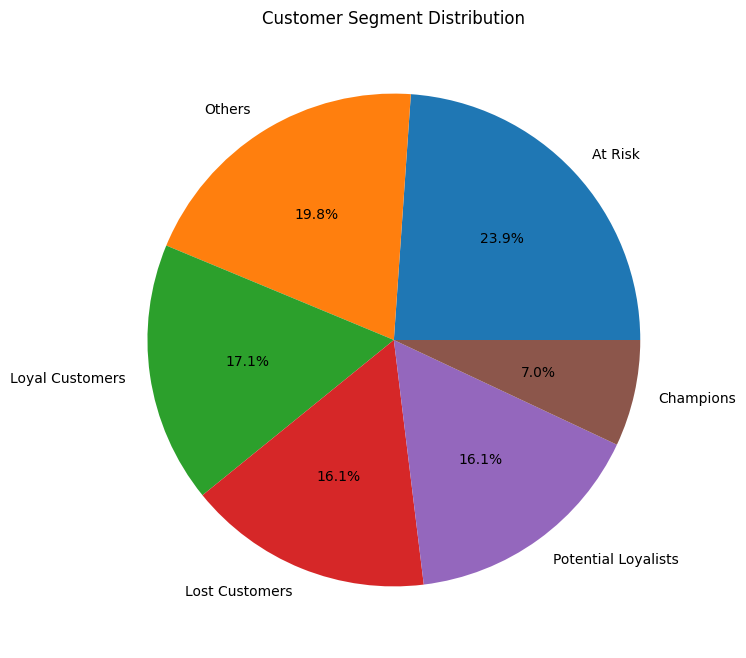

In [18]:
segment_count.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8,8)
)

plt.ylabel('')
plt.title('Customer Segment Distribution')

plt.show()

# Valued Customers Table

In [19]:
champions = (
    rfm[rfm['Segment']=='Champions']
    .sort_values(
        'Monetary',
        ascending=False
    )
)

champions.head(20)

,customer_unique_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
26456,46450c74a0d8c5ca9395da1daac6c120,61,3,9553.02,5,5,5,555,Champions
75269,c8460e4251689ba205045f3ea17884a1,71,4,4655.91,5,5,5,555,Champions
89385,edde2314c6c30e864a128ac95d6b2112,75,1,4513.32,5,5,5,555,Champions
60913,a229eba70ec1c2abef51f04987deb7a5,139,1,4445.50,5,4,5,545,Champions
93998,fa562ef24d41361e476e748681810e1e,203,1,4175.26,4,5,5,455,Champions
75984,ca27f3dac28fb1063faddd424c9d95fa,81,1,4163.51,5,4,5,545,Champions
90302,f0767ae738c3d90e7b737d7b8b8bb4d1,157,1,3979.55,4,5,5,455,Champions
77476,ce3fe361f9e68bf0a813baaae1334d01,64,1,3351.35,5,4,5,545,Champions
65407,adfa1cab2b2c8706db21bb13c0a1beb1,138,1,3242.84,5,4,5,545,Champions
70625,bbeb907759ef5fc169099af3c88d535d,174,1,3209.72,4,4,5,445,Champions


In [20]:
champions = rfm[rfm['Segment'] == 'Champions'].copy()

lost = rfm[rfm['Segment'] == 'Lost Customers'].copy()

In [21]:
champions[['Frequency','Monetary']].describe()

,Frequency,Monetary
count,6712.00,6712.00
mean,1.19,317.50
std,0.52,337.41
min,1.00,133.25
25%,1.00,164.82
50%,1.00,213.73
75%,1.00,329.60
max,17.00,9553.02


In [22]:
champion_freq_threshold = champions['Frequency'].median()

champion_monetary_threshold = champions['Monetary'].median()

print(champion_freq_threshold)
print(champion_monetary_threshold)

1.0
213.72999572753906


In [23]:
lost_high_value = lost[
    (
        lost['Frequency']
        >= champion_freq_threshold
    )
    &
    (
        lost['Monetary']
        >= champion_monetary_threshold
    )
]

In [24]:
print(
    f"High Value Lost Customers: {len(lost_high_value)}"
)

High Value Lost Customers: 2908


In [25]:
len(lost_high_value) / len(lost) * 100

18.806182500161675

In [26]:
lost_high_value.sort_values(
    'Monetary',
    ascending=False
).head(10)

,customer_unique_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
3826,0a0a92112bd4c708ca5fde585afaa872,384,1,13664.08,2,1,5,215,Lost Customers
24121,4007669dec559734d6f53e029e360987,328,1,6081.54,2,2,5,225,Lost Customers
35581,5e713be0853d8986528d7869a0811d2b,620,1,4042.74,1,2,5,125,Lost Customers
426,011875f0176909c5cf0b14a9138bb691,578,1,4016.91,1,1,5,115,Lost Customers
34175,5aad27a7b4f74b1c3389d56c74db1057,596,1,3782.19,1,2,5,125,Lost Customers
35067,5d09b0d82126457e2a8ebfb9c9a1ffc4,615,1,3736.22,1,2,5,125,Lost Customers
1320,03796b63235e0e0a299084988c662c7e,603,1,3602.47,1,1,5,115,Lost Customers
5825,0f75637a7e2f7b6ae43665d1f7d0ca5d,588,1,3044.12,1,1,5,115,Lost Customers
16138,2ae8173a688e326821403a5b7a6858c2,576,1,3042.36,1,1,5,115,Lost Customers
36727,6172bd5b7f52ade8c6c4548b448ff54f,469,1,3041.73,1,2,5,125,Lost Customers


In [27]:
high_value_ids = (
    lost_high_value[
        'customer_unique_id'
    ]
)

In [28]:
sales.columns.tolist()

['sales_key',
 'order_id',
 'customer_id',
 'product_id',
 'seller_id',
 'order_date',
 'payment_value',
 'freight_value',
 'quantity',
 'city_customer',
 'state_customer',
 'customer_sk',
 'category',
 'weight',
 'product_sk',
 'city_seller',
 'state_seller',
 'seller_sk',
 'date',
 'year',
 'month',
 'quarter',
 'week',
 'day',
 'month_name',
 'day_name']

In [29]:
sales = sales.merge(
    customers[
        [
            'customer_id',
            'customer_unique_id'
        ]
    ],
    on='customer_id',
    how='left'
)

In [30]:
high_value_sales = sales[
    sales['customer_unique_id']
    .isin(high_value_ids)
]

In [31]:
high_value_sales.groupby(
    'category'
)['payment_value'] \
.sum() \
.sort_values(
    ascending=False
).head(15)

category
relogios_presentes       317228.32
informatica_acessorios   301890.16
moveis_decoracao         253377.48
ferramentas_jardim       245910.86
beleza_saude             242047.84
telefonia_fixa           233594.86
moveis_escritorio        229767.86
esporte_lazer            220833.90
cama_mesa_banho          215569.08
cool_stuff               196470.58
automotivo               182818.88
pcs                      116607.38
brinquedos               113004.58
perfumaria               110488.50
utilidades_domesticas     94551.36
Name: payment_value, dtype: float64

In [32]:
champion_sales = sales[
    sales['customer_unique_id']
    .isin(
        champions[
            'customer_unique_id'
        ]
    )
]

In [33]:
champion_category = (
    champion_sales.groupby(
        'category'
    )['payment_value']
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

In [34]:
lost_category = (
    high_value_sales.groupby(
        'category'
    )['payment_value']
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

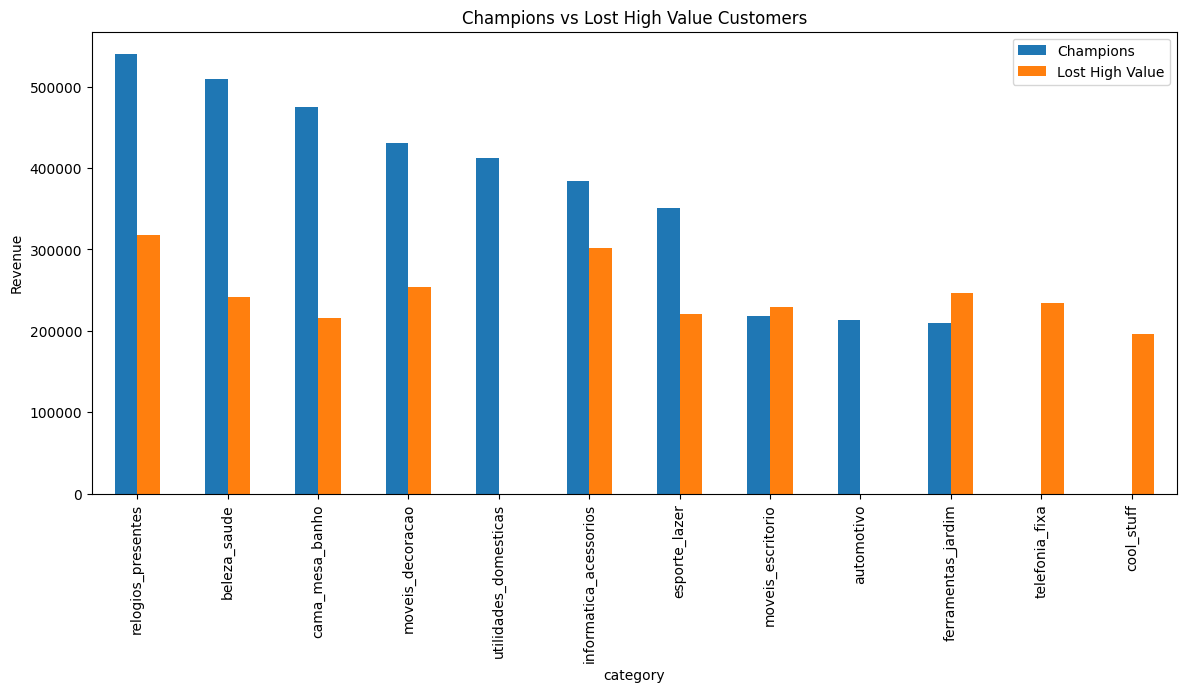

In [35]:

comparison = pd.concat(
    [
        champion_category,
        lost_category
    ],
    axis=1
)

comparison.columns = [
    'Champions',
    'Lost High Value'
]

comparison.fillna(0)\
.sort_values(
    'Champions',
    ascending=False
)\
.plot(
    kind='bar',
    figsize=(14,6)
)

plt.title(
    'Champions vs Lost High Value Customers'
)

plt.ylabel('Revenue')

plt.show()

# Executive Analysis: Champions vs. Lost High Value Customers

## 1. Overview
This notebook presents a comprehensive analysis of the revenue generated by **Champions** (loyal, high-frequency, high-spending customers) compared to the potential revenue lost from **Lost High-Value Customers** across various product categories. 

The primary objective is to quantify the financial impact of customer churn and estimate the total potential revenue if these valuable accounts had been retained.

---

## 2. Revenue Breakdown by Category (Estimated)

| Category | Champions Revenue ($) | Lost High Value Revenue ($) | Potential Total Revenue ($) | Status / Risk Level |
| :--- | :---: | :---: | :---: | :--- |
| **relogios_presentes** | 540,000 | 318,000 | 858,000 | High Loss, Strong Baseline |
| **beleza_saude** | 510,000 | 242,000 | 752,000 | Moderate Loss, High Revenue |
| **cama_mesa_banho** | 475,000 | 216,000 | 691,000 | Moderate Loss, Stable |
| **moveis_decoracao** | 430,000 | 255,000 | 685,000 | High Churn Risk |
| **utilidades_domesticas** | 412,000 | 0 | 412,000 | Perfect Retention |
| **informatica_acessorios**| 385,000 | 302,000 | 687,000 | Severe Churn Risk |
| **esporte_lazer** | 352,000 | 222,000 | 574,000 | Moderate Loss |
| **moveis_escritorio** | 218,000 | 230,000 | 448,000 | **Critical**: Lost > Current |
| **automotivo** | 214,000 | 0 | 214,000 | Perfect Retention |
| **ferramentas_jardim** | 210,000 | 248,000 | 458,000 | **Critical**: Lost > Current |
| **telefonia_fixa** | 0 | 235,000 | 235,000 | **Total Collapse** (No Champions)|
| **cool_stuff** | 0 | 197,000 | 197,000 | **Total Collapse** (No Champions)|

---

## 3. Financial Summary & Potential Revenue Impact

If the company had successfully prevented the churn of these high-value customers, the total financial standing would look as follows:

* **Current Revenue (Champions):** `$3,746,000`
* **Total Lost Revenue (Opportunity Cost):** `$2,465,000`
* **Maximum Potential Revenue:** **`$6,211,000`**

### Key Financial Insight
> **Revenue Increase Percentage:** If customer retention strategies were fully effective, the company's total revenue would have been **65.8% higher** than its current level. 

---

## 4. Strategic Observations & Action Items

### 🔴 Critical Alerts (Immediate Intervention Required)
1. **Total Segment Collapse (`telefonia_fixa` & `cool_stuff`):** These categories currently generate **zero** revenue from Champion customers. The entire top-tier customer base has been lost. Immediate product-market fit evaluation or aggressive win-back campaigns are required.
2. **Negative Balance (`ferramentas_jardim` & `moveis_escritorio`):** In these sectors, the lost revenue actually **outweighs** the current revenue from active loyal customers. The business is shrinking rapidly in these markets.

### 🟢 Strengths to Leverage
1. **Perfect Retention (`utilidades_domesticas` & `automotivo`):** These categories show zero churn among high-value customers. The retention playbook used for these segments should be analyzed and applied to weak segments.
2. **Top Performers (`relogios_presentes` & `beleza_saude`):** These remain the highest revenue drivers, but they also represent a huge absolute value of lost revenue. Even a 10% reduction in churn here will yield massive dollar amounts.

---

## 5. Recommended Next Steps
* **Win-Back Campaigns:** Target historical high-value clients in `telefonia_fixa` and `cool_stuff` with personalized offers.
* **Churn Cause Analysis:** Conduct interviews or surveys with churned users in high-loss categories like `informatica_acessorios` to understand pricing or quality issues.
* **Cross-Pollination:** Identify why `utilidades_domesticas` performs so perfectly in retention and replicate its customer success model.